In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import math
import pickle

In [3]:
with open('../results/distribution_all_gene.pkl', 'rb') as f:
    distribution = pickle.load(f)

with open('../results/precision_all_gene_pearson.pkl', 'rb') as f:
    precision = pickle.load(f)

In [4]:

def plot_model_comparison_2rows(ours_dict, title="Performance Comparison"):
    """
    Plots violin plots in a 2-column grid.
    Statistics (Mean ± Std) are written textually under the title.
    """
    # 1. Merge Data
    data_list = []
    
    # Process OURS
    for metric, scores in ours_dict.items():
        if hasattr(scores, 'cpu'): scores = scores.cpu().numpy()
        if np.isscalar(scores): scores = [scores]
        for s in scores:
            data_list.append({'Model': 'Ours', 'Metric': metric, 'Value': s})
            
    df = pd.DataFrame(data_list)
    unique_metrics = df['Metric'].unique()
    n_metrics = len(unique_metrics)
    
    # 2. Setup Grid (Fixed 2 Columns)
    n_cols = 2
    n_rows = math.ceil(n_metrics / n_cols)
    
    sns.set_theme(style="whitegrid", context="paper", font_scale=1.4)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 5 * n_rows), sharey=False)
    
    # Flatten axes array for easy iteration (handles 1D and 2D arrays)
    axes = axes.flatten() if n_metrics > 1 else [axes]
    
    my_palette = {"Ours": "#2ecc71"}
    
    # 3. Plot Loop
    for i, metric in enumerate(unique_metrics):
        ax = axes[i]
        subset = df[df['Metric'] == metric]
        
        # A. Violin & Strip Plot
        sns.violinplot(
            data=subset, x='Model', y='Value',
            palette=my_palette, inner="quart", cut=0, linewidth=1.5, ax=ax
        )
        sns.stripplot(
            data=subset, x='Model', y='Value',
            color="black", size=3, alpha=0.3, jitter=True, ax=ax
        )
        
        # B. Calculate Stats
        stats_msg = []
        for model in ['Ours']:
            vals = subset[subset['Model'] == model]['Value']
            if len(vals) > 0:
                mean_v = np.mean(vals)
                std_v = np.std(vals)
                stats_msg.append(f"{model}: {mean_v:.3f} ± {std_v:.3f}")
        
        # Join stats with a separator
        full_stats_text = "  |  ".join(stats_msg)
        
        # C. Styling & Text Placement
        ax.set_title(metric, fontweight='bold', pad=25) # Increase pad to make room
        ax.set_xlabel("")
        ax.set_ylabel("")
        
        # Place text relative to axes (x=0.5 is center, y=1.02 is just above top border)
        ax.text(
            0.5, 1.02, 
            full_stats_text, 
            transform=ax.transAxes, 
            ha='center', 
            va='bottom', 
            fontsize=12, 
            color='#333333',
            fontweight='medium'
        )
        
        sns.despine(ax=ax)

    # 4. Cleanup Empty Subplots (if odd number of metrics)
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.suptitle(title, fontweight='bold', fontsize=18, y=1.02) # Lift main title up
    plt.tight_layout()
    plt.show()



/tmp/ipykernel_3486964/1605451987.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_3486964/1605451987.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_3486964/1605451987.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_3486964/1605451987.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_3486964/160545198

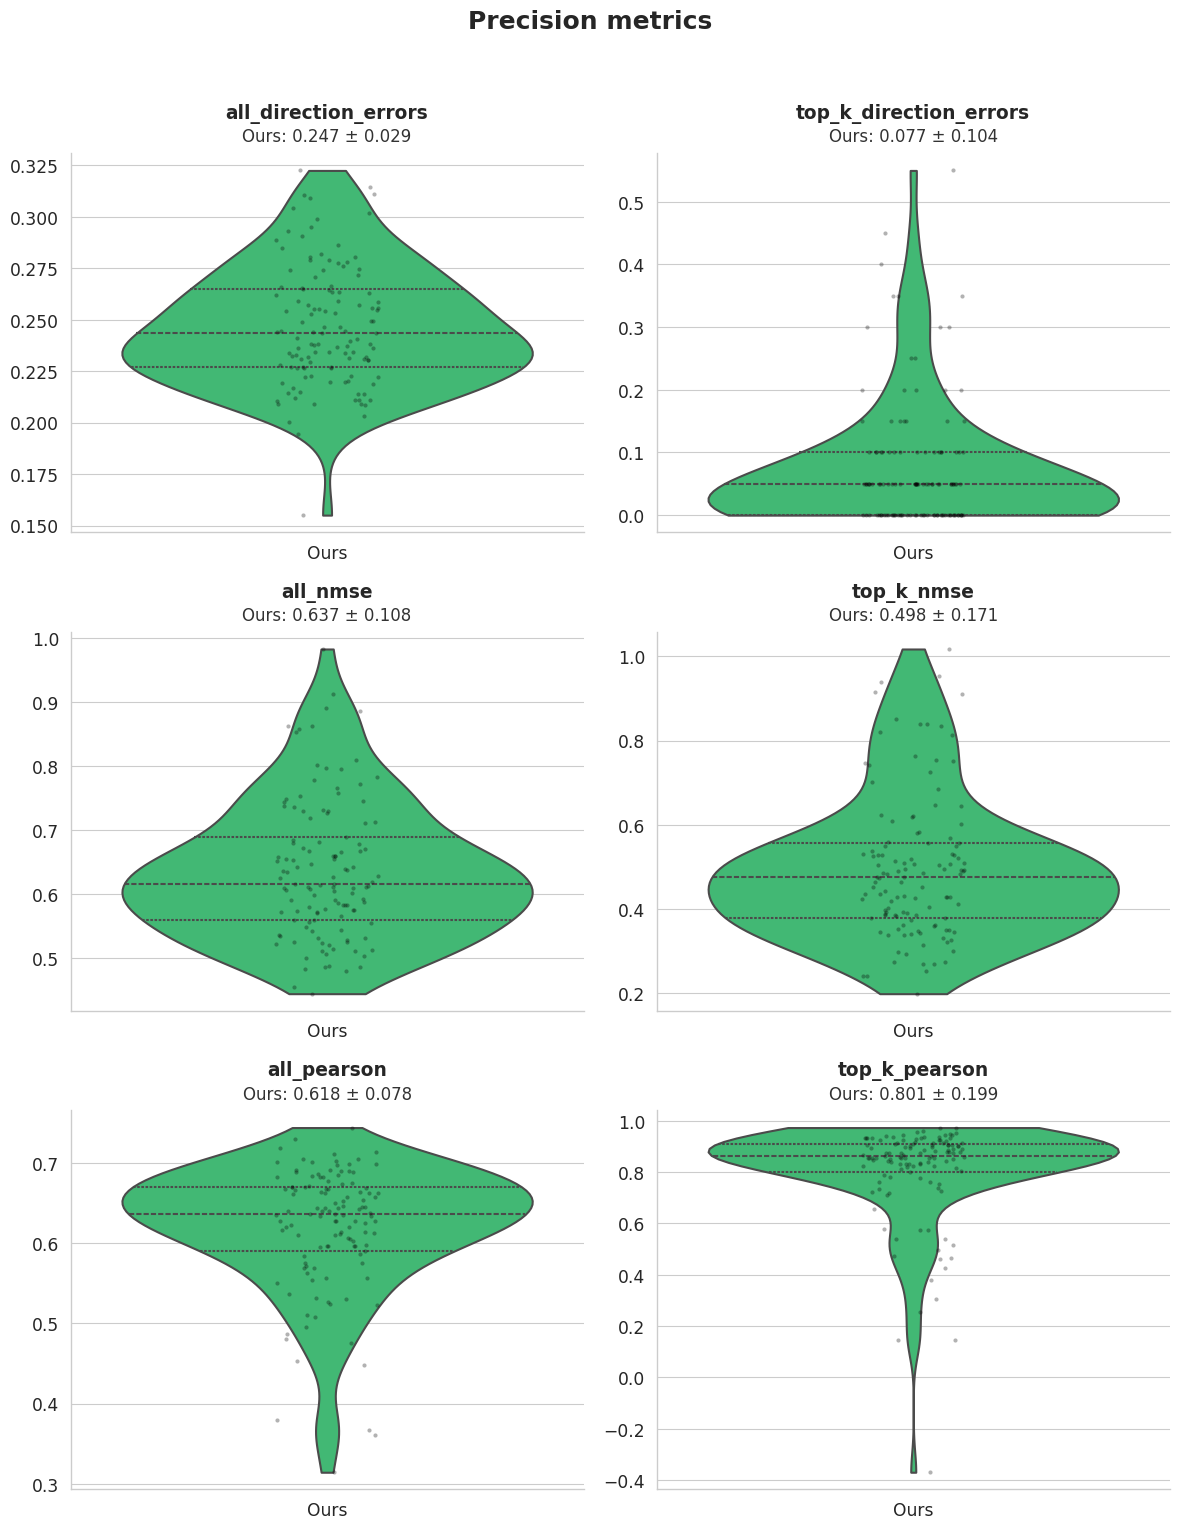

In [5]:
plot_model_comparison_2rows(precision, title="Precision metrics")

/tmp/ipykernel_3486964/1605451987.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_3486964/1605451987.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_3486964/1605451987.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_3486964/1605451987.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_3486964/160545198

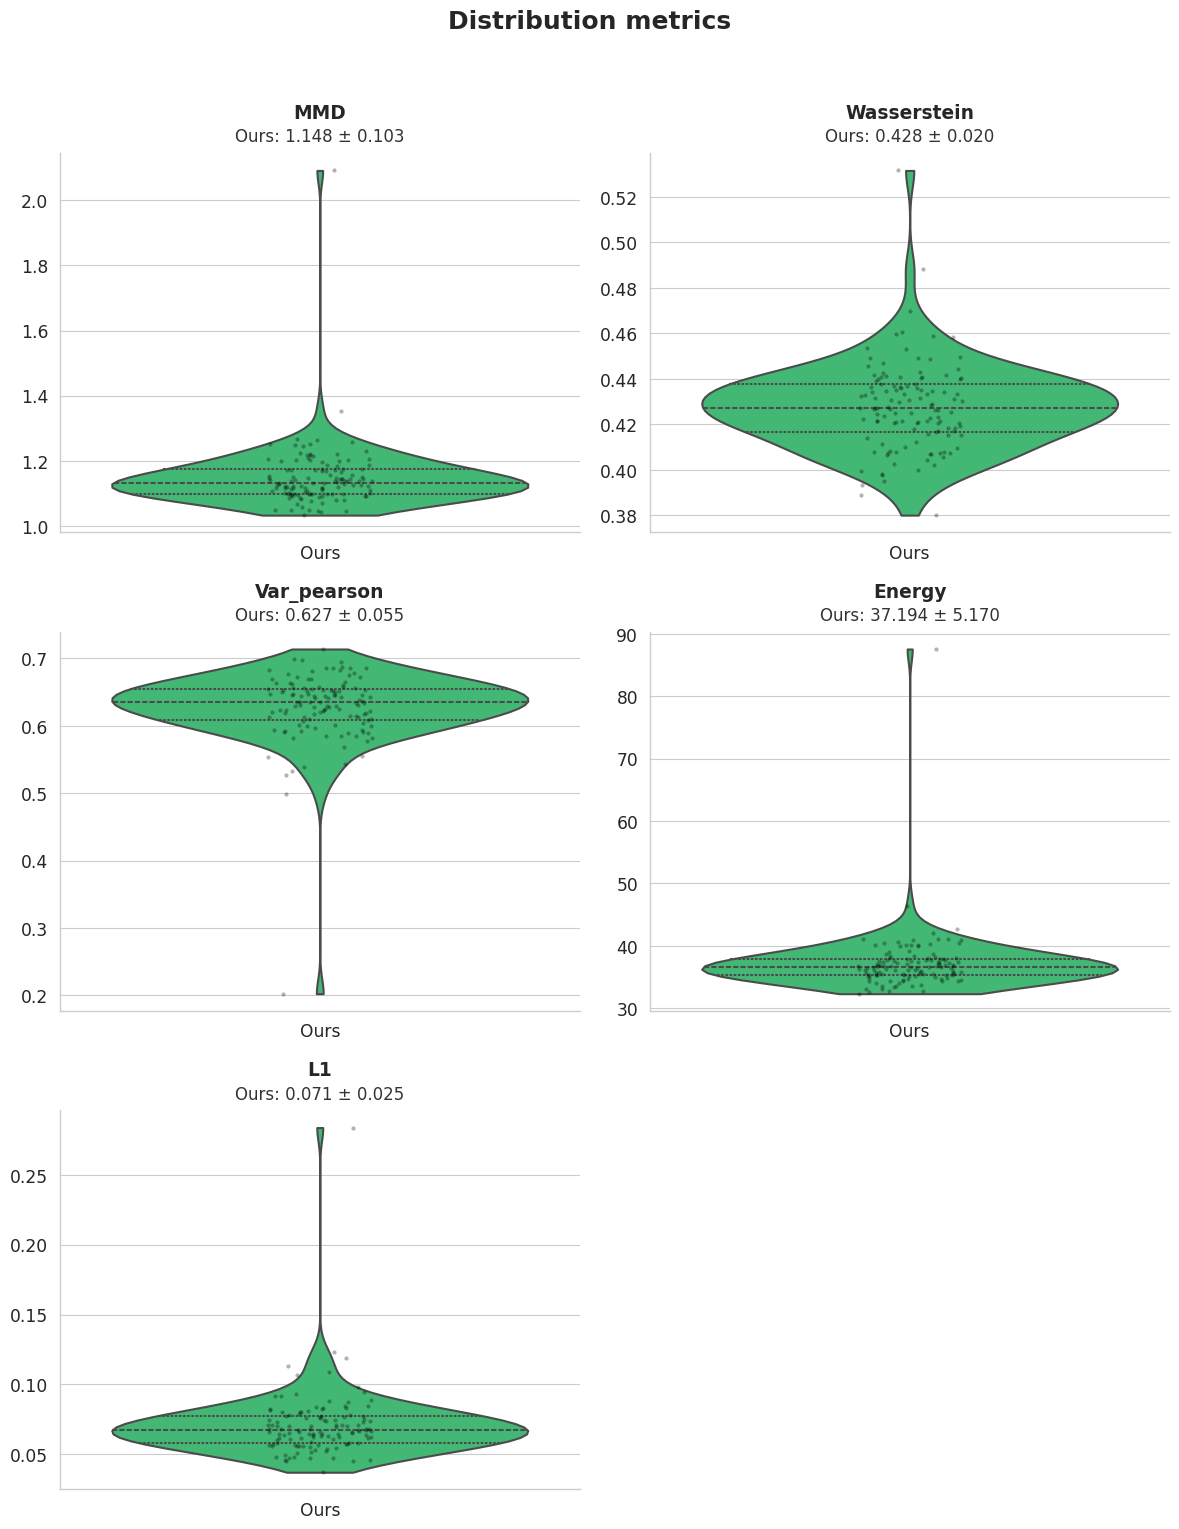

In [6]:
plot_model_comparison_2rows(distribution, title="Distribution metrics")